# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [92]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [93]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [94]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [95]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [96]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [97]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [98]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [99]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [100]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [101]:
# cantidad de nulos para users
print(f'Suma de valores nulos x columna\n{users.isna().sum()}')
print(f'Promedio de valores nulos x columna\n{users.isna().mean()}')

Suma de valores nulos x columna
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Promedio de valores nulos x columna
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [102]:
# cantidad de nulos para usage
print(f'Suma de valores nulos x columna\n{usage.isna().sum()}')
print(f'Promedio de valores nulos x columna\n{usage.isna().mean()}')

Suma de valores nulos x columna
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Promedio de valores nulos x columna
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: \
- El dataset de `users` presenta solo dos columnas con `valores nulos`, `city` y `churn_date`. La columna `city` solo presenta 11% de valores nulos, por lo que se podrían imputar con la ciudad con la frecuencia más alta. Por otro lado, la columna `churn_date` presenta más de un 85% de valores nulos; por ende, se podría ignorar en caso de que no sea necesaria para el análisis.
- El dataset `usage` tiene tres columnas con valores nulos, `date`, `duration` y `length`. La columna `date` prácticamente tiene una cantidad insignificante de valores nulos, por lo que se podrían dejar como nulos. Por otro lado, la columna `duration` tiene un 55% de valores faltantes. Convendría revisar el motivo de estos registros. Podría indicar usuarios que no realizaron esta acción. Es decir, los valores nulos de `duration` significarían que el usuario mandó un mensaje en vez de llamar o viceversa. Sin embargo, podría haber errores en caso de que no se haya registrado la llamada o el mensaje. Como sugerencia, se podrían mantener los datos nulos desde que haya al menos un registro de `duration` o `length` por cada usuario.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [103]:
# explorar columnas numéricas de users
print(f'Resumen estadístico \n{users.describe()}')

Resumen estadístico 
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` contiene identificadores únicos de los usuarios. En total se registran 4000 usuarios, sin valores duplicados ni valores nulos, lo que indica que cada fila corresponde a un usuario distinto.
- La columna `age` describe la edad de los usuarios. Las edades registradas varían entre -999 y 79 años, con una media de 33.7 años y una mediana de 47 años. La diferencia entre ambas medidas sugiere una distribución sesgada hacia la izquierda, posiblemente influenciada por valores muy bajos. El rango intercuartílico es de 31 años, lo que indica una dispersión considerable en el 50 % central de las edades. Cabe señalar que estas métricas pueden estar afectadas por valores atípicos o inválidos, como edades negativas o el valor -999, que probablemente corresponde a un error o marcador de datos faltantes.

In [104]:
# explorar columnas numéricas de usage
print(f'Resumen estadístico \n{usage.describe()}')

Resumen estadístico 
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` corresponden, respectivamente, al identificador del registro de uso y al identificador del cliente. Dado que el dataset contiene 40000 registros y los valores de `user_id` se repiten a lo largo de los registros, se infiere que un mismo cliente puede tener múltiples eventos de uso asociados.
- Las columnas `duration` y `length` recogen los detalles de uso: la duración de la llamada y la longitud del mensaje. La duración de las llamadas varía entre 0 y 120 minutos, con una media de 5.2 minutos y una mediana de 3.5 minutos, lo que sugiere una distribución sesgada a la derecha, probablemente influida por llamadas inusualmente largas. Por su parte, la longitud de los mensajes varía entre 0 y 1490 caracteres, con una media de 52.1 y una mediana de 50, lo que indica una distribución más centrada, aunque con algunos valores altos que podrían considerarse atípicos.

In [105]:
cols_categoricas = ['city', 'plan']
print(f'Resumen estadístico \n{users[cols_categoricas].describe()}')

Resumen estadístico 
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` toma 3531 registros con pocos valores nulos. Recoge 7 ciudades únicas, siendo Bogotá la más comun con una frecuencia de 808.
- La columna `plan` presenta 4000 entradas con dos valores únicos, **Basico** o **Premium**. De estos dos, el que más se repite es el plan **Basico** con 2595 registros en total.

In [106]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` incluye dos valores únicos, **text** y **call**. De los 40000 registros presentes, **text** es el más común con 2092 entradas más que **text**. 


---
✍️ **Comentario**: \
En el dataset `users`, la columna `age` tiene un outlier que afecta la distribución de la edad. Este valor es un dígito alto negativo, lo cual indica un sesgo a la izquierda. Se recomendaría revisar a qué se debe este valor y si hay más outliers de este tipo. Como solución, se podría reemplazar por la edad con mayor frecuencia, ya que la media no es confiable en este contexto. Por el contrario, sería mejor eliminar las filas correspondientes a este valor. Por otro lado, la columna `city` tiene algunos valores nulos, por lo que se podrían ignorar en caso de no necesitarlos y tomarlos por la ciudad con mayor frecuencia.\
Con respecto al dataset `usage` conviene revisar los datos de las columnas `length` y `duration` debido a que no se especifica el tipo de valor (minutos, segundos, horas, caracteres, palabras, etc.) Se da por hecho que son minutos en el caso de `duration` y caracteres para `length`. De no ser así, habría que revisar los valores superiores, ya que serían extraños.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [107]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [108]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [109]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

- En `reg_date` se recogen los años de 2022 a 2026, exceptuando 2025. Según el conteo de cada uno, 2026 es un año muy nuevo con pocos registros, mientras que los demás años sobrepasan los 1300 registros.

In [110]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

- La columna `date` solo presenta los registros del año 2024, estos son en total 39950. Sin embargo, una pequeña muestra, al menos 50 entradas, no tiene un valor válido para el año.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: \
En general, no parece haber ningún año fuera de rango en el dataset `users`. Por otro lado, en `usage` es recomendable validar el formato del año en específico. 

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [111]:
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [112]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [113]:
# Marcar fechas futuras como NA para reg_date
# Importar libreria para obtener fecha de hoy
import datetime as dt

# Definir variables
today = pd.Timestamp.now()

# Reemplazar fechas invalidas por NA
users.loc[users['reg_date'] > today, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [114]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [115]:
# Verificación MAR en usage (Missing At Random) para length

usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

- De acuerdo a la verificación, las columnas `duration` y `length` dependen de la variable de la columna `type`. Lo que quiere decir que la mayoría de los valores faltantes no parecen ser errores.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [116]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
        .groupby("user_id")
        .agg(
            cant_mensajes=("is_text", "sum"),
            cant_llamadas=("is_call", "sum"),
            cant_minutos_llamada=("duration", "sum")
        )
        .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [117]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on='user_id', how='left')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [118]:
# Resumen estadístico de las columnas numéricas
numeric_cols = ['cant_mensajes','cant_llamadas','cant_minutos_llamada','age']
user_profile[numeric_cols].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [119]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

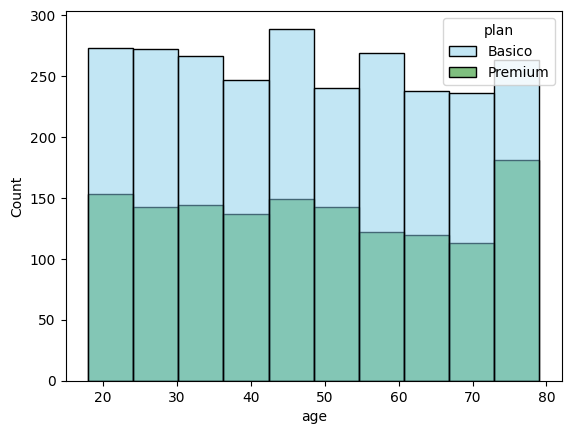

In [120]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights: 
- La distribución de edad no parece estar muy dispersa; sin embargo, un buen número de usuarios suele estar en el rango de 40 a 50 años.
- Una gran cantidad de clientes pertenecen al plan básico.
- No hay una relación clara entre la edad y el plan escogid

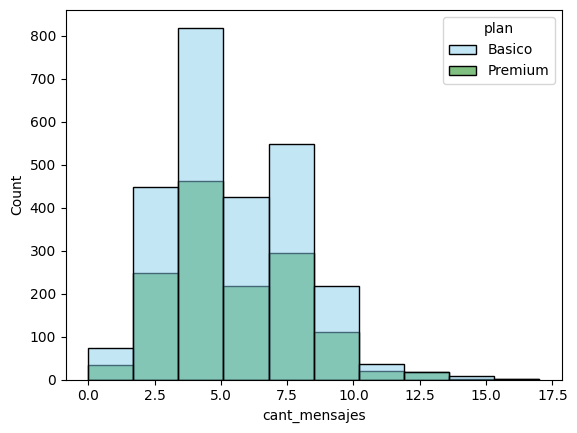

In [121]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights: 
- Los usuarios premium tienden a enviar más mensajes en promedio. Sin embargo, hay una mayor cantidad de planes básicos.
- La mayoría de los mensajes se concentran entre 3 y 8. Esto indicaría que el uso típico se encuentra en este rango.
- El plan premium muestra mayor cantidad de mensajes (+10). Por lo tanto, los usuarios Premium tienden a tener un mayor uso. No obstante, un bajo uso se acumula en ambos; el plan básico aparenta tener menos mensajes.

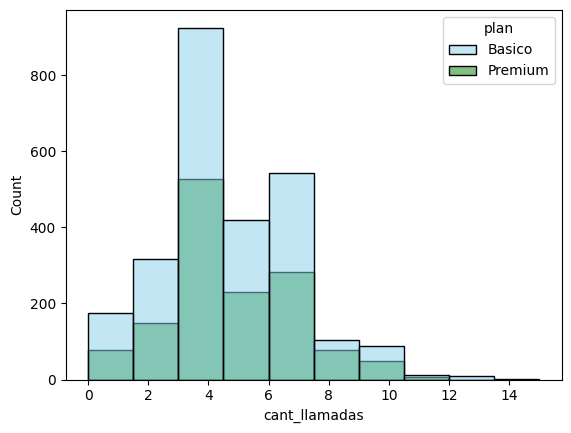

In [122]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights: 
- La mayoría de los usuarios se concentran entre 3 y 7 llamadas.
- Básico:
  - Tiene más volumen total (las barras son más altas).
  - Mayor dispersión → hay más usuarios con valores altos (hasta ~14–15 llamadas)
- Premium:
  - Más concentrado en el rango 3 a 6 llamadas.
  - Menos casos extremos.
- Al igual que los mensajes, hay mayor cantidad de usuarios de Básico, pero los de Premium tienden a tener un uso más intensivo.
- Conviene revisar si el plan Premium incentiva el uso.

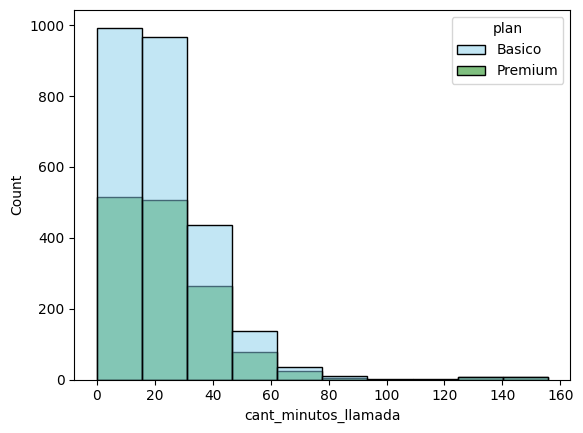

In [123]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights: 
- La mayoría de las llamadas duran menos de 30 minutos. Quiere decir que la mayoría de usuarios, tanto Básico como Premium no superan los 30 minutos por llamada.
- Los usuarios Premium muestran mayor presencia relativa en llamadas largas
- Hay un sesgo a la derecha, indicando que algunas llamadas superaron los 120 minutos. (revisar si son outliers o casos reales de alto valor)
- Existe una asociación entre Premium y llamadas más largas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

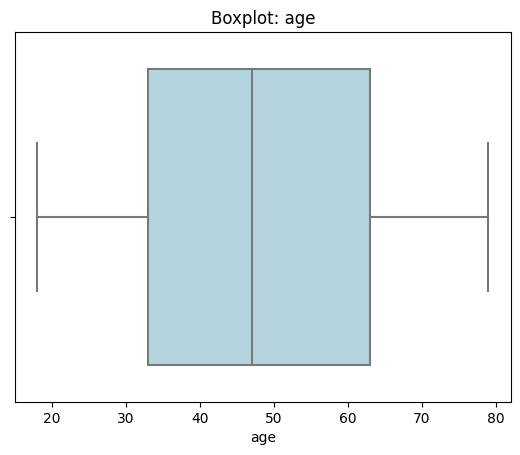

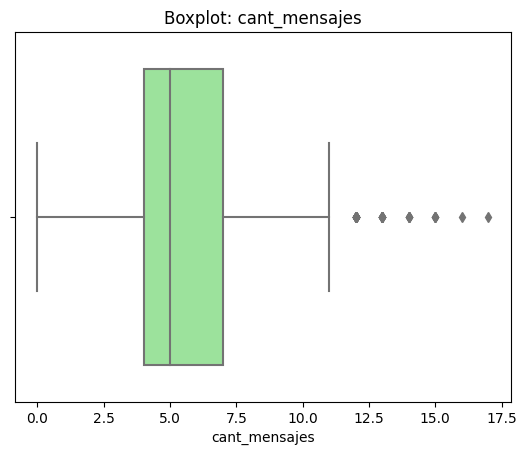

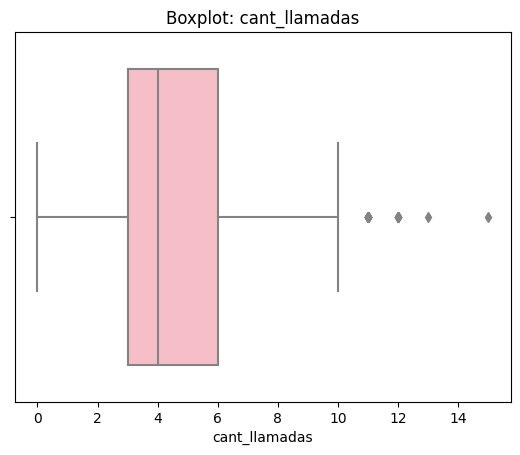

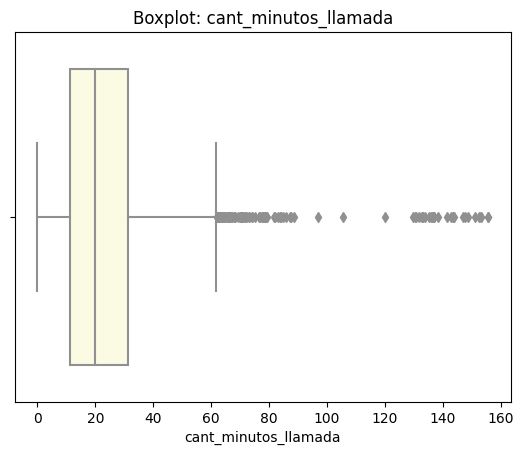

In [124]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
colors = ['lightblue', 'lightgreen', 'lightpink', 'lightyellow']

for col, color in zip(columnas_numericas, colors):
    sns.boxplot(data=user_profile, x=col, color=color)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: presenta dos outliers significativos. Una edad muy alta o baja, pero pueden ser reales debido a que una gran parte de los usuarios se concentra entre 40 y 50 años.
- cant_mensajes: La distribución está sesgada a la derecha, lo que significa que hay pocos usuarios muy activos. Hay un grupo pequeño de usuarios que tienen un uso mayor al resto, lo cual generaría los outliers. Se puede decir que los valores normales se centran entre 3 y 8 mensajes.
- cant_llamadas: La mediana está alrededor de 4 llamadas y parece concentrarse entre 3 y 6 llamadas. Sin embargo, parecido a los mensajes, hay algunos usuarios que tienen un uso más intensivo, lo que genera un sesgo a la derecha.
- cant_minutos_llamada: La mediana se encuentra en 20 minutos y la mayoría ronda entre 10 y 30 minutos. También presenta un sesgo a la derecha, indicando que gran parte de los usuarios se mantiene en llamada poco tiempo. 

In [125]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
limites = {}

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    limites[col] = {
        'Q1': q1,
        'Q3': q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper
    }
limites

{'cant_mensajes': {'Q1': 4.0,
  'Q3': 7.0,
  'IQR': 3.0,
  'lower_bound': -0.5,
  'upper_bound': 11.5},
 'cant_llamadas': {'Q1': 3.0,
  'Q3': 6.0,
  'IQR': 3.0,
  'lower_bound': -1.5,
  'upper_bound': 10.5},
 'cant_minutos_llamada': {'Q1': 11.12,
  'Q3': 31.415,
  'IQR': 20.295,
  'lower_bound': -19.322500000000005,
  'upper_bound': 61.8575}}

In [126]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Los outliers representan casos de usuarios con un uso alto más que errores, por lo tanto, mantener.
- cant_llamadas: La distribución sesgada a la derecha indica la variabilidad en el comportamiento de los usuarios, por lo que no es inusual ver valores altos.
- cant_minutos_llamada: Existen valores extremos alejados del promedio, pero pueden reflejar diferentes tipos de llamadas, como conversaciones largas o llamadas de servicio al cliente. Por ende, mantener outliers.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [127]:
# Crear columna grupo_uso
# Condiciones de uso medio y bajo
conditions = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Opciones
usage_rtng = ['Bajo uso', 'Uso medio']

# Crear columna basado en el las condiciones *Alto uso por defecto*
user_profile['grupo_uso'] = np.select(conditions, usage_rtng, default='Alto uso')

In [128]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [129]:
# Crear columna grupo_edad
# Condiciones de edad, joven, adulto
conditions = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# Opciones
age_clas = ['Joven', 'Adulto']

# Crear columna basado en el las condiciones *Adulto mayor por defecto*
user_profile['grupo_edad'] = np.select(conditions, age_clas, default='Adulto Mayor')

In [130]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

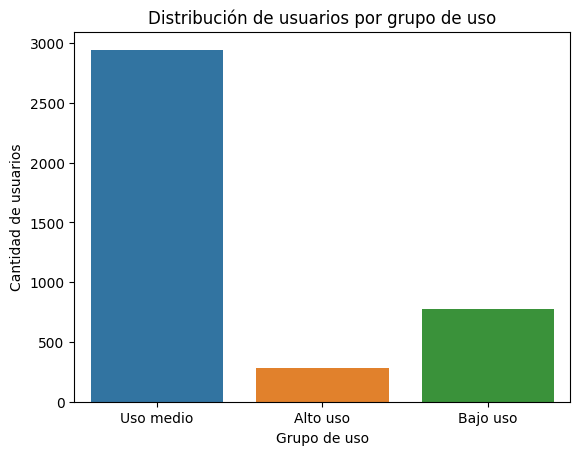

In [131]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile)
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

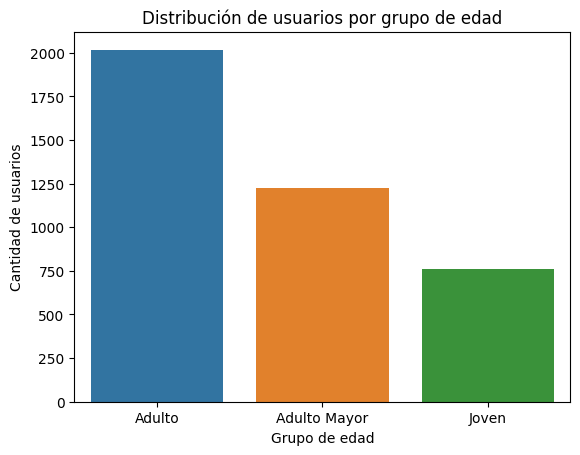

In [132]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron outliers en variables de uso, especialmente en minutos de llamada, con valores muy por encima del promedio.
- Estos casos representan una minoría, pero corresponden a usuarios intensivos y no a errores, por lo que se mantuvieron.
- No se detectaron muchas inconsistencias graves (valores negativos o imposibles), lo que indica buena calidad general de los datos.


🔍 **Segmentos por Edad**
- La distribución por edad es bastante uniforme, aunque el grupo Adulto sigue siendo el más representativo.
- No hay una diferencia drástica entre planes según edad. Esto sugiere que el plan no está fuertemente segmentado por edad actualmente.


📊 **Segmentos por Nivel de Uso**
- Predomina el Uso medio, lo que indica un comportamiento estable en la mayoría de los usuarios.
- El segmento de Alto uso es reducido pero estratégico.
- El segmento de Bajo uso podría representar usuarios poco comprometidos o con bajo valor actual.


**Análisis por plan**
- El plan Básico domina en cantidad de usuarios en todas las variables.
- El plan Premium no muestra una diferencia clara en comportamiento de uso frente al Básico:
- Distribuciones muy similares en mensajes, llamadas y minutos.
- No hay evidencia fuerte de que los usuarios Premium consuman significativamente más.
- El plan Premium no está claramente diferenciado en términos de uso.
➡️ Esto sugiere que ...
- Muchos usuarios Premium podrían estar subutilizando el plan, lo que implica:
- Poca percepción de valor
- Riesgo de downgrade o churn
- El plan Básico cubre suficientemente las necesidades de la mayoría de usuarios.
- Los usuarios de alto uso no están necesariamente concentrados en el plan Premium → oportunidad perdida. 

💡 **Recomendaciones**
- Rediseñar el plan Premium:
  - Incluir beneficios claros (ilimitado, бонус, perks exclusivos)
  - Diferenciarlo realmente del plan Básico
- Estrategia de upselling:
  - Identificar usuarios de alto uso en plan Básico
  - Ofrecer migración a Premium con incentivos
- Activar usuarios de bajo uso:
  - Promociones, paquetes pequeños o descuentos
- Segmentación más inteligente:
  - Crear planes basados en comportamiento real (heavy callers vs heavy texters)
- Análisis adicional recomendado:
  - Cruce directo: grupo_uso vs plan
  - Esto confirmaría si el Premium está mal posicionado

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/JCardenas73/telecom-analysis
